# Multiple Linear Regression 

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import joblib

## Load dataset

In [2]:
df_encoded = pd.read_csv("../dataset/medical_insurance_encoded.csv")
df_encoded.head()

,cat__sex_male,cat__smoker_yes,cat__region_northwest,cat__region_southeast,cat__region_southwest,remainder__age,remainder__bmi,remainder__children,remainder__smoker_bmi,remainder__age_squared,remainder__age_smoker,remainder__is_underweight,remainder__is_obese,remainder__obese_smoker,remainder__children_smoker,charges
0,0.0,1.0,0.0,0.0,1.0,19.0,27.900,0.0,27.9,361.0,19.0,0.0,0.0,0.0,0.0,16884.92400
1,1.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,0.0,324.0,0.0,0.0,1.0,0.0,0.0,1725.55230
2,1.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,0.0,784.0,0.0,0.0,1.0,0.0,0.0,4449.46200
3,1.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,0.0,1089.0,0.0,0.0,0.0,0.0,0.0,21984.47061
4,1.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,0.0,1024.0,0.0,0.0,0.0,0.0,0.0,3866.85520


In [3]:
df_encoded.shape

(1337, 16)

## Split features x and y

In [4]:
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

y_log = np.log1p(y) 

In [5]:
X.head()

,cat__sex_male,cat__smoker_yes,cat__region_northwest,cat__region_southeast,cat__region_southwest,remainder__age,remainder__bmi,remainder__children,remainder__smoker_bmi,remainder__age_squared,remainder__age_smoker,remainder__is_underweight,remainder__is_obese,remainder__obese_smoker,remainder__children_smoker
0,0.0,1.0,0.0,0.0,1.0,19.0,27.900,0.0,27.9,361.0,19.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,1.0,0.0,18.0,33.770,1.0,0.0,324.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,1.0,0.0,28.0,33.000,3.0,0.0,784.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,1.0,0.0,0.0,33.0,22.705,0.0,0.0,1089.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,1.0,0.0,0.0,32.0,28.880,0.0,0.0,1024.0,0.0,0.0,0.0,0.0,0.0


In [6]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

## Train and test

In [7]:
X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(X, y, y_log, test_size=0.2, random_state=42) 
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (1069, 15)
Test set shape: (268, 15)


## Create and train MLR model

In [8]:
model = LinearRegression()
model.fit(X_train, y_train_log) 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[-0.08, 2. ,-0.03,..., 0.04, 0.47,-0.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['cat__sex_male','cat__smoker_yes','cat__region_northwest',..., 'remainder__is_obese','remainder__obese_smoker', 'remainder__children_smoker']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.955
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(15)


## Inspect coefficients

In [9]:
coefficients = pd.DataFrame({"Feature": X.columns, "Coefficient": model.coef_}).sort_values(by="Coefficient", ascending=False)
print("Intercept:", model.intercept_)
coefficients 

Intercept: 6.954887790169468


,Feature,Coefficient
1,cat__smoker_yes,2.000056
13,remainder__obese_smoker,0.473282
7,remainder__children,0.121443
5,remainder__age,0.057158
12,remainder__is_obese,0.044284
8,remainder__smoker_bmi,0.022327
9,remainder__age_squared,-0.000201
6,remainder__bmi,-0.003489
2,cat__region_northwest,-0.028889
10,remainder__age_smoker,-0.032679


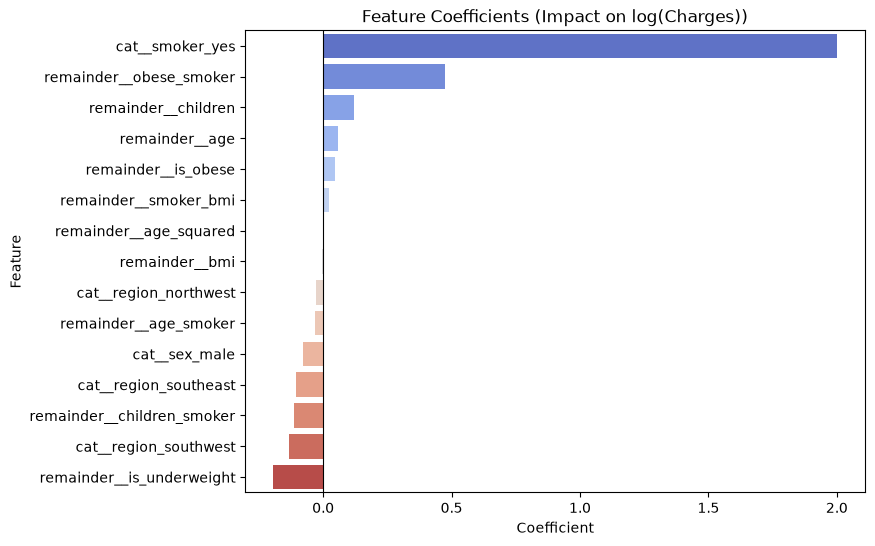

In [10]:
plt.figure(figsize=(8,6))

sns.barplot(data=coefficients, x="Coefficient", y="Feature", hue="Feature", palette="coolwarm", legend=False)

plt.title("Feature Coefficients (Impact on log(Charges))") 
plt.axvline(0, color="black", linewidth=0.8)

plt.show()

## Predict on test set

In [11]:
y_pred_log = model.predict(X_test) 
y_pred = np.expm1(y_pred_log) 

## Evaluate

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

MAE:  2284.28
MSE:  18844793.89
RMSE: 4341.06
R2 Score: 0.8974


## Visualize Actual vs Predicted Charges

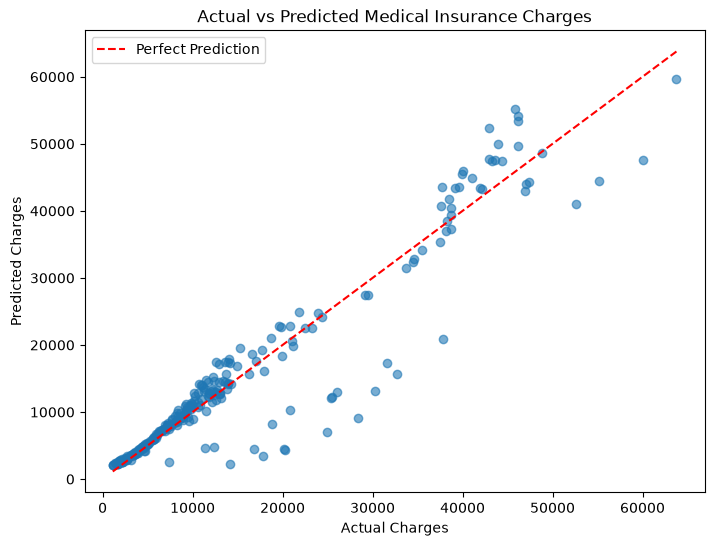

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Insurance Charges")
plt.legend()

plt.show()

## Residual analysis

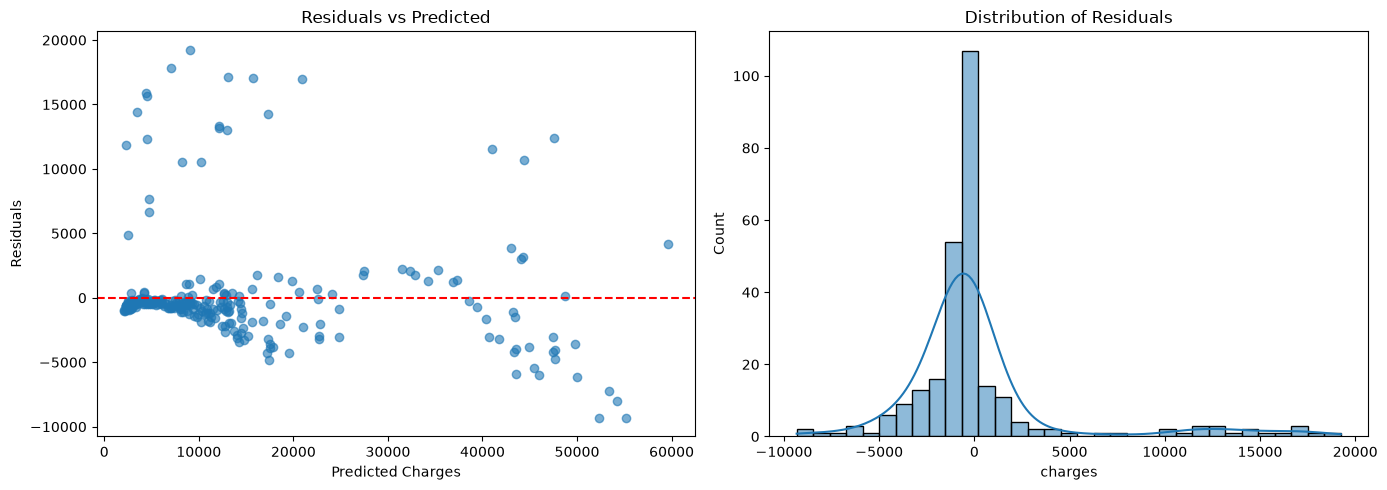

In [14]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Charges")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

## 5 Fold Cross Validation

In [15]:
cv_scores = cross_val_score(model, X, y_log, cv=5, scoring='r2')
print("R² per fold:", cv_scores)
print(f"Mean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

R² per fold: [0.88672067 0.72953149 0.9010204  0.83239581 0.80712323]
Mean R²: 0.8314 ± 0.0614


## Save the trained model

In [15]:
joblib.dump(model, "../models/MLR_model.pkl")
print("Model saved.")

Model saved.


In [16]:
print(model.feature_names_in_)

['cat__sex_male' 'cat__smoker_yes' 'cat__region_northwest'
 'cat__region_southeast' 'cat__region_southwest' 'remainder__age'
 'remainder__bmi' 'remainder__children' 'remainder__smoker_bmi'
 'remainder__age_squared' 'remainder__age_smoker'
 'remainder__is_underweight' 'remainder__is_obese'
 'remainder__obese_smoker' 'remainder__children_smoker']


## Predict on new data

In [17]:
# new_person = {  
#     "age": 35,  
#     "sex": "male",         # "male" or "female"  
#     "bmi": 28.5,  
#     "children": 2,  
#     "smoker": "yes",       # "yes" or "no" 
#     "region": "southeast"  # "northeast", "northwest", "southeast", "southwest" 
# } 

### Encode new person as training data

In [18]:
# preprocessor = joblib.load("../models/preprocessor.pkl") 

# def encode_new_person(person, columns): 
#     smoker_flag = 1 if person["smoker"] == "yes" else 0  

#     raw_row = pd.DataFrame([{  
#         "age": person["age"],  
#         "sex": person["sex"],  
#         "bmi": person["bmi"],  
#         "children": person["children"], 
#         "smoker": person["smoker"], 
#         "region": person["region"],  
#         "smoker_bmi": smoker_flag * person["bmi"],  
#         "age_squared": person["age"] ** 2,  
#         "age_smoker": person["age"] * smoker_flag, 
#         "is_underweight": int(person["bmi"] < 18.5),  
#         "is_obese": int(person["bmi"] >= 30),  
#         "obese_smoker": int(person["bmi"] >= 30) * smoker_flag, 
#         "children_smoker": person["children"] * smoker_flag, 
#     }]) 

#     encoded = preprocessor.transform(raw_row)  
#     df = pd.DataFrame(encoded, columns=preprocessor.get_feature_names_out())  

#     return df[columns]  

## Save New Person

In [19]:
# new_person_encoded = encode_new_person(new_person, X.columns) 
# new_person_encoded 

### Predict

In [20]:
# predicted_log_charge = model.predict(new_person_encoded)[0]  
# predicted_charge = np.exp(predicted_log_charge)  
# print(f"Predicted insurance charge: ${predicted_charge:,.2f}")  